In [1]:
!pip -q install timm==1.0.9

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 29.0 MB/s eta 0:00:00


# Imports

In [2]:
# Using only sklearn/torchvision built-ins to keep it lightweight.

import os, math, json, random, glob, time, itertools, shutil
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, roc_auc_score,
    average_precision_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import label_binarize
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (6, 6)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


# Mount Drive & Paths

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA_ROOT = "/content/drive/MyDrive/Dataset"
IMG_DIR = os.path.join(DATA_ROOT, "images")
ANN_DIR = os.path.join(DATA_ROOT, "annotations")

assert os.path.isdir(IMG_DIR) and os.path.isdir(ANN_DIR), "Fix DATA_ROOT paths."
print("Found", len(os.listdir(IMG_DIR)), "images and", len(os.listdir(ANN_DIR)), "annotation files.")


Mounted at /content/drive
Found 3999 images and 15996 annotation files.


# Configurations

In [4]:
@dataclass
class TrainConfig:
    img_size: int = 224
    batch_size: int = 32
    num_workers: int = 2
    epochs: int = 10
    lr: float = 3e-4
    weight_decay: float = 1e-4
    val_split: float = 0.15  # 15% of training goes to validation
    num_classes: int = 8

CFG = TrainConfig()
print(CFG)


TrainConfig(img_size=224, batch_size=32, num_workers=2, epochs=10, lr=0.0003, weight_decay=0.0001, val_split=0.15, num_classes=8)


# Dataset & Reader

In [5]:
class AffectDataset(Dataset):
    def __init__(self, image_dir: str, ann_dir: str,
                 transform: Optional[transforms.Compose] = None):
        self.image_dir = image_dir
        self.ann_dir = ann_dir
        self.transform = transform

        # Build index from images that have all needed annotations
        self.items = []
        for jpg in sorted(glob.glob(os.path.join(image_dir, "*.jpg"))):
            stem = os.path.splitext(os.path.basename(jpg))[0]
            exp = os.path.join(ann_dir, f"{stem}_exp.npy")
            val = os.path.join(ann_dir, f"{stem}_val.npy")
            aro = os.path.join(ann_dir, f"{stem}_aro.npy")
            if os.path.exists(exp) and os.path.exists(val) and os.path.exists(aro):
                self.items.append(stem)

        assert len(self.items) > 0, "No aligned samples found. Check file names."
        print(f"[AffectDataset] usable samples: {len(self.items)}")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        stem = self.items[idx]
        img_path = os.path.join(self.image_dir, f"{stem}.jpg")
        exp_path = os.path.join(self.ann_dir, f"{stem}_exp.npy")
        val_path = os.path.join(self.ann_dir, f"{stem}_val.npy")
        aro_path = os.path.join(self.ann_dir, f"{stem}_aro.npy")

        # Load
        img = Image.open(img_path).convert("RGB")
        exp = int(np.load(exp_path).item() if np.load(exp_path).shape == () else np.load(exp_path).astype(int))
        val = float(np.load(val_path).item() if np.load(val_path).shape == () else float(np.load(val_path)))
        aro = float(np.load(aro_path).item() if np.load(aro_path).shape == () else float(np.load(aro_path)))

        if self.transform:
            img = self.transform(img)

        # Outputs
        exp = torch.tensor(exp, dtype=torch.long)
        vra = torch.tensor([val, aro], dtype=torch.float32)
        return img, exp, vra, stem


# Data Augmentation - Transforms & Split

In [6]:
# Data augmentation (on-the-fly)
train_tfms = transforms.Compose([
    transforms.Resize((CFG.img_size, CFG.img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.2, contrast=0.2)], p=0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((CFG.img_size, CFG.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

full_ds = AffectDataset(IMG_DIR, ANN_DIR, transform=None)  # temp to count
n = len(full_ds)
val_n = int(CFG.val_split * n)
train_n = n - val_n
indices = list(range(n))
random.shuffle(indices)
train_idx, val_idx = indices[:train_n], indices[train_n:]

# Rebuild with transforms but same indexing
raw_ds = AffectDataset(IMG_DIR, ANN_DIR, transform=None)
train_ds = Subset(AffectDataset(IMG_DIR, ANN_DIR, transform=train_tfms), train_idx)
val_ds   = Subset(AffectDataset(IMG_DIR, ANN_DIR, transform=val_tfms),   val_idx)

def collate(batch):
    imgs, exps, vras, stems = zip(*batch)
    return torch.stack(imgs), torch.stack(exps), torch.stack(vras), list(stems)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                          num_workers=CFG.num_workers, pin_memory=True, collate_fn=collate)
val_loader   = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False,
                          num_workers=CFG.num_workers, pin_memory=True, collate_fn=collate)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")


[AffectDataset] usable samples: 3999
[AffectDataset] usable samples: 3999
[AffectDataset] usable samples: 3999
[AffectDataset] usable samples: 3999
Train: 3400 | Val: 599


# Multi-Task Model (Backbone-agnostic)

Wraps a torchvision backbone and adds:
     
      - classification head: num_classes
      - regression head: 2 outputs [valence, arousal]

In [7]:
class MultiTaskCNN(nn.Module):
    def __init__(self, backbone_name: str, num_classes: int = 8, pretrained: bool = True):
        super().__init__()
        self.backbone_name = backbone_name.lower()

        if self.backbone_name == "efficientnet_b0":
            base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None)
            in_feats = base.classifier[-1].in_features
            base.classifier[-1] = nn.Identity()
            self.backbone = base

        elif self.backbone_name == "mobilenet_v3_large":
            base = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1 if pretrained else None)
            in_feats = base.classifier[-1].in_features
            base.classifier[-1] = nn.Identity()
            self.backbone = base

        else:
            raise ValueError(f"Unknown backbone: {backbone_name}")

        self.head_cls = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_feats, num_classes)
        )
        self.head_reg = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_feats, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        feats = self.backbone(x)
        logits = self.head_cls(feats)
        v_a = self.head_reg(feats)
        return logits, v_a


# Losses & Metrics (Continuous + Classification)

Krippendorff’s α (nominal) is implemented for two “raters” (GT vs prediction). AUC/AUPRC are macro-averaged OvR.

In [8]:
class MultiTaskLoss(nn.Module):
    def __init__(self, cls_weight: float = 1.0, reg_weight: float = 0.5):
        super().__init__()
        self.cls_weight = cls_weight
        self.reg_weight = reg_weight
        self.ce = nn.CrossEntropyLoss()
        self.mse = nn.MSELoss()

    def forward(self, logits, y_cls, y_reg):
        lc = self.ce(logits, y_cls)
        lr = self.mse(y_reg, y_reg.detach())  # placeholder (overridden below)
        return lc + self.reg_weight * lr

def multitask_loss(logits, y_cls, pred_reg, y_reg, reg_weight=0.5):
    ce = F.cross_entropy(logits, y_cls)
    mse = F.mse_loss(pred_reg, y_reg)
    return ce + reg_weight * mse, ce.item(), mse.item()

# ---- Continuous metrics ----
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def pearson_corr(y_true, y_pred):
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return 0.0
    return float(pearsonr(y_true, y_pred)[0])

def sagr(y_true, y_pred):
    # Sign Agreement Ratio over both valence & arousal
    signs_true = np.sign(y_true)
    signs_pred = np.sign(y_pred)
    return float(np.mean(signs_true == signs_pred))

def ccc(y_true, y_pred):
    # Lin's Concordance Correlation Coefficient
    x = y_true; y = y_pred
    mx, my = np.mean(x), np.mean(y)
    vx, vy = np.var(x), np.var(y)
    cov = np.mean((x - mx) * (y - my))
    return float((2 * cov) / (vx + vy + (mx - my) ** 2 + 1e-8))

# ---- Krippendorff's Alpha (nominal) for 2 raters (gt vs pred) ----
def krippendorff_alpha_nominal(gt: np.ndarray, pred: np.ndarray):
    assert gt.shape == pred.shape
    cats = np.unique(np.concatenate([gt, pred]))
    n = len(gt)
    # disagreement function: 1 if different, else 0
    Do = np.sum(gt != pred) / n
    # Expected disagreement by chance:
    # estimate category marginals from pooled counts
    pooled = np.concatenate([gt, pred])
    counts = np.array([np.sum(pooled == c) for c in cats], dtype=float)
    p = counts / pooled.size
    De = 1.0 - np.sum(p ** 2)
    if De == 0:
        return 1.0
    return 1.0 - Do / De


# Train / Validate Loops

In [9]:
def train_one_epoch(model, loader, optimizer, scaler, cfg: TrainConfig, log_interval: int = 20):
    """
    Train model for one epoch.
    """
    model.train()
    total_loss, total_ce, total_mse = 0.0, 0.0, 0.0
    correct, total = 0, 0

    for batch_idx, (imgs, y_cls, y_reg, _) in enumerate(loader, start=1):
        imgs, y_cls, y_reg = imgs.to(device), y_cls.to(device), y_reg.to(device)
        optimizer.zero_grad(set_to_none=True)

        # forward + loss
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits, pred_reg = model(imgs)
            loss, ce_val, mse_val = multitask_loss(logits, y_cls, pred_reg, y_reg, reg_weight=0.5)

        # backward + step
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # accumulate
        total_loss += loss.item() * imgs.size(0)
        total_ce   += ce_val * imgs.size(0)
        total_mse  += mse_val * imgs.size(0)

        # running accuracy
        preds = logits.argmax(dim=1)
        correct += (preds == y_cls).sum().item()
        total   += y_cls.size(0)

        if batch_idx % log_interval == 0 or batch_idx == len(loader):
            running_acc = 100. * correct / total
            print(f"  Batch {batch_idx}/{len(loader)} "
                  f"| Loss={loss.item():.4f} "
                  f"| Running Acc={running_acc:.2f}%")

    n = len(loader.dataset)
    return total_loss/n, total_ce/n, total_mse/n


@torch.no_grad()
def evaluate(model, loader):
    """
    Evaluate model on validation/test set.
    Computes classification (ACC, F1, Kappa, Alpha, AUC, AUPR)
    and regression (RMSE, CORR, SAGR, CCC) metrics.
    """
    model.eval()
    all_logits, all_cls, all_reg, all_pred_reg, stems_all = [], [], [], [], []

    for imgs, y_cls, y_reg, stems in loader:
        imgs = imgs.to(device)
        logits, pred_reg = model(imgs)

        all_logits.append(logits.cpu())
        all_pred_reg.append(pred_reg.cpu())
        all_cls.append(y_cls)
        all_reg.append(y_reg)
        stems_all.extend(stems)

    logits = torch.cat(all_logits); y_cls = torch.cat(all_cls)
    pred_reg = torch.cat(all_pred_reg); y_reg = torch.cat(all_reg)

    # Classification metrics
    probs = torch.softmax(logits, dim=1).numpy()
    y_true = y_cls.numpy()
    y_pred = probs.argmax(1)

    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro')
    kappa = cohen_kappa_score(y_true, y_pred)
    alpha = krippendorff_alpha_nominal(y_true, y_pred)

    try:
        y_bin = label_binarize(y_true, classes=list(range(CFG.num_classes)))
        auc_macro = roc_auc_score(y_bin, probs, average='macro', multi_class='ovr')
        aupr_macro = average_precision_score(y_bin, probs, average='macro')
    except Exception:
        auc_macro, aupr_macro = np.nan, np.nan

    # Regression metrics
    y_val_true = y_reg[:,0].numpy(); y_aro_true = y_reg[:,1].numpy()
    y_val_pred = pred_reg[:,0].numpy(); y_aro_pred = pred_reg[:,1].numpy()

    rmse_val = rmse(y_val_true, y_val_pred); rmse_aro = rmse(y_aro_true, y_aro_pred)
    corr_val = pearson_corr(y_val_true, y_val_pred); corr_aro = pearson_corr(y_aro_true, y_aro_pred)
    sagr_val = sagr(y_val_true, y_val_pred); sagr_aro = sagr(y_aro_true, y_aro_pred)
    ccc_val = ccc(y_val_true, y_val_pred); ccc_aro = ccc(y_aro_true, y_aro_pred)

    metrics = {
        "ACC": acc, "F1_macro": f1m, "Kappa": kappa, "Alpha": alpha,
        "AUC_macro": auc_macro, "AUPR_macro": aupr_macro,
        "RMSE_val": rmse_val, "RMSE_aro": rmse_aro,
        "CORR_val": corr_val, "CORR_aro": corr_aro,
        "SAGR_val": sagr_val, "SAGR_aro": sagr_aro,
        "CCC_val": ccc_val, "CCC_aro": ccc_aro,
        "y_true": y_true, "y_pred": y_pred, "probs": probs,
        "stems": stems_all, "y_reg_true": y_reg.numpy(), "y_reg_pred": pred_reg.numpy()
    }
    return metrics


# Orchestrator (Train a Backbone)

In [10]:
def train_backbone(backbone_name: str, epochs: int = None):
    epochs = epochs or CFG.epochs
    model = MultiTaskCNN(backbone_name, num_classes=CFG.num_classes, pretrained=True).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    history = {"train_loss": [], "train_ce": [], "train_mse": [],
               "val_ACC": [], "val_F1": []}

    best_acc, best_state = -1, None
    start = time.time()
    for ep in range(1, epochs+1):
        print("="*50)
        print(f"[{backbone_name.upper()}] Epoch {ep}/{epochs}")
        print("="*50)

        tr_loss, tr_ce, tr_mse = train_one_epoch(model, train_loader, optimizer, scaler, CFG)
        val_metrics = evaluate(model, val_loader)

        history["train_loss"].append(tr_loss)
        history["train_ce"].append(tr_ce)
        history["train_mse"].append(tr_mse)
        history["val_ACC"].append(val_metrics["ACC"])
        history["val_F1"].append(val_metrics["F1_macro"])

        # Progress report
        print(f"Train -> Loss={tr_loss:.4f}, CE={tr_ce:.4f}, MSE={tr_mse:.4f}")
        print(f"Val   -> ACC={val_metrics['ACC']:.4f}, F1={val_metrics['F1_macro']:.4f}, "
              f"Kappa={val_metrics['Kappa']:.4f}, Alpha={val_metrics['Alpha']:.4f}")
        print(f"AUC={val_metrics['AUC_macro']:.4f}, AUPR={val_metrics['AUPR_macro']:.4f}")
        print("-"*50)

        if val_metrics["ACC"] > best_acc:
            best_acc = val_metrics["ACC"]
            best_state = {
                "model": model.state_dict(),
                "metrics": val_metrics,
                "history": history,
                "cfg": CFG.__dict__,
                "backbone": backbone_name
            }

    dur = time.time() - start
    print(f"[{backbone_name}] best ACC={best_acc:.4f} | time={dur/60:.1f} min")
    return best_state


# Train Baselines
    - efficientnet_b0
    - mobilenet_v3_large



In [11]:
effb0_best    = train_backbone("efficientnet_b0", epochs=CFG.epochs)
mbv3_best  = train_backbone("mobilenet_v3_large", epochs=CFG.epochs)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 86.4MB/s]


[EFFICIENTNET_B0] Epoch 1/10


/tmp/ipython-input-4010521729.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipython-input-377905002.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


  Batch 20/107 | Loss=2.1388 | Running Acc=16.56%
  Batch 40/107 | Loss=2.0300 | Running Acc=18.91%
  Batch 60/107 | Loss=1.8763 | Running Acc=21.88%
  Batch 80/107 | Loss=1.8963 | Running Acc=24.38%
  Batch 100/107 | Loss=1.9291 | Running Acc=25.78%
  Batch 107/107 | Loss=2.2408 | Running Acc=26.24%
Train -> Loss=1.9619, CE=1.8765, MSE=0.1708
Val   -> ACC=0.3673, F1=0.3432, Kappa=0.2774, Alpha=0.2702
AUC=0.7951, AUPR=0.3879
--------------------------------------------------
[EFFICIENTNET_B0] Epoch 2/10


...

  Batch 20/107 | Loss=0.2495 | Running Acc=90.31%
  Batch 40/107 | Loss=0.3751 | Running Acc=89.92%
  Batch 60/107 | Loss=0.2884 | Running Acc=89.06%
  Batch 80/107 | Loss=0.2843 | Running Acc=89.41%
  Batch 100/107 | Loss=0.1860 | Running Acc=89.66%
  Batch 107/107 | Loss=0.8709 | Running Acc=89.56%
Train -> Loss=0.3426, CE=0.3119, MSE=0.0614
Val   -> ACC=0.4858, F1=0.4798, Kappa=0.4114, Alpha=0.4097
AUC=0.8179, AUPR=0.4617
--------------------------------------------------
[MOBILENET_V3_LARGE] Epoch 9/10


/tmp/ipython-input-377905002.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


  Batch 20/107 | Loss=0.2354 | Running Acc=90.47%
  Batch 40/107 | Loss=0.3791 | Running Acc=90.78%
  Batch 60/107 | Loss=0.1776 | Running Acc=90.62%
  Batch 80/107 | Loss=0.3221 | Running Acc=90.00%
  Batch 100/107 | Loss=0.1734 | Running Acc=90.09%
  Batch 107/107 | Loss=0.7100 | Running Acc=90.06%
Train -> Loss=0.3250, CE=0.2949, MSE=0.0601
Val   -> ACC=0.4224, F1=0.4224, Kappa=0.3407, Alpha=0.3368
AUC=0.8088, AUPR=0.4472
--------------------------------------------------
[MOBILENET_V3_LARGE] Epoch 10/10


/tmp/ipython-input-377905002.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


  Batch 20/107 | Loss=0.2639 | Running Acc=90.31%
  Batch 40/107 | Loss=0.2230 | Running Acc=91.88%
  Batch 60/107 | Loss=0.2557 | Running Acc=92.08%
  Batch 80/107 | Loss=0.1635 | Running Acc=92.50%
  Batch 100/107 | Loss=0.3235 | Running Acc=92.97%
  Batch 107/107 | Loss=0.6475 | Running Acc=92.97%
Train -> Loss=0.2407, CE=0.2139, MSE=0.0537
Val   -> ACC=0.4274, F1=0.4226, Kappa=0.3437, Alpha=0.3417
AUC=0.8128, AUPR=0.4327
--------------------------------------------------
[mobilenet_v3_large] best ACC=0.4858 | time=12.1 min


# Training Curves

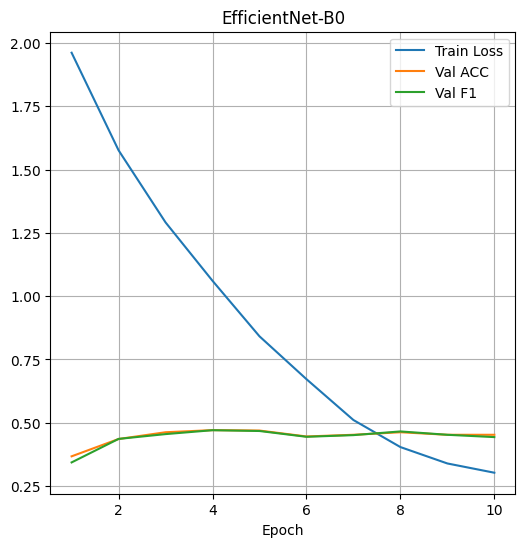

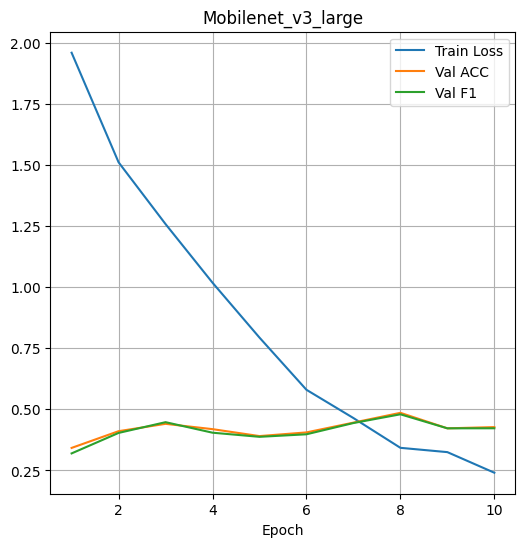

In [12]:
def plot_history(history, title="Training"):
    xs = list(range(1, len(history["train_loss"])+1))
    fig, ax = plt.subplots()
    ax.plot(xs, history["train_loss"], label="Train Loss")
    ax.plot(xs, history["val_ACC"], label="Val ACC")
    ax.plot(xs, history["val_F1"], label="Val F1")
    ax.set_xlabel("Epoch"); ax.set_title(title); ax.grid(True); ax.legend()
    plt.show()

plot_history(effb0_best["history"], title="EfficientNet-B0")
plot_history(mbv3_best["history"], title="Mobilenet_v3_large")


# Full Metric Tables + Confusion Matrix

In [13]:
def summarize_metrics(best_state, name):
    m = best_state["metrics"]
    table = {
        "Model": [name],
        "ACC":[m["ACC"]], "F1_macro":[m["F1_macro"]],
        "Kappa":[m["Kappa"]], "Alpha":[m["Alpha"]],
        "AUC_macro":[m["AUC_macro"]], "AUPR_macro":[m["AUPR_macro"]],
        "RMSE_val":[m["RMSE_val"]], "RMSE_aro":[m["RMSE_aro"]],
        "CORR_val":[m["CORR_val"]], "CORR_aro":[m["CORR_aro"]],
        "SAGR_val":[m["SAGR_val"]], "SAGR_aro":[m["SAGR_aro"]],
        "CCC_val":[m["CCC_val"]], "CCC_aro":[m["CCC_aro"]],
    }
    return pd.DataFrame(table)

eff_df = summarize_metrics(effb0_best, "EfficientNetB0")
mob_df = summarize_metrics(mbv3_best, "Mobilenet_v3_large")
comp_df = pd.concat([eff_df, mob_df], ignore_index=True)
comp_df.style.format(precision=4)


,Model,ACC,F1_macro,Kappa,Alpha,AUC_macro,AUPR_macro,RMSE_val,RMSE_aro,CORR_val,CORR_aro,SAGR_val,SAGR_aro,CCC_val,CCC_aro
0,EfficientNetB0,0.4708,0.4705,0.3954,0.3940,0.8378,0.4862,0.3772,0.3511,0.6121,0.4881,0.7629,0.7496,0.5783,0.4040
1,Mobilenet_v3_large,0.4858,0.4798,0.4114,0.4097,0.8179,0.4617,0.4027,0.3487,0.5435,0.3922,0.7579,0.7913,0.4803,0.3442


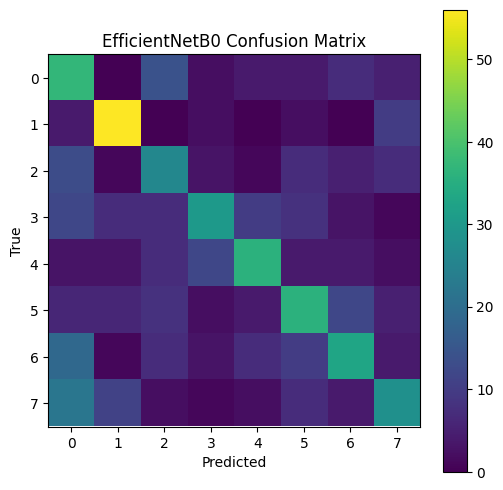

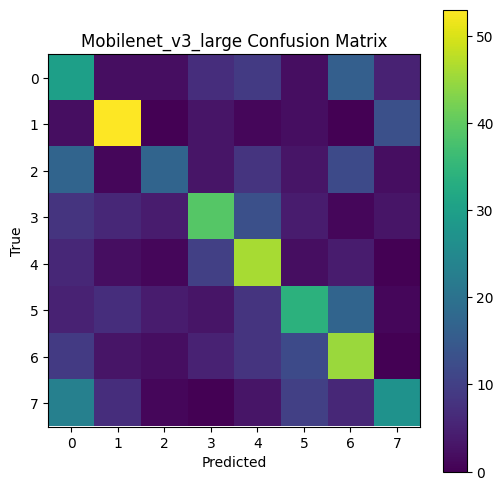

In [14]:
# Confusion matrix for best model
def plot_conf_matrix(best_state, name):
    y_true = best_state["metrics"]["y_true"]
    y_pred = best_state["metrics"]["y_pred"]
    cm = confusion_matrix(y_true, y_pred, labels=list(range(CFG.num_classes)))
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest')
    ax.figure.colorbar(im, ax=ax)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks(range(CFG.num_classes)); ax.set_yticks(range(CFG.num_classes))
    plt.show()

plot_conf_matrix(effb0_best, "EfficientNetB0")
plot_conf_matrix(mbv3_best, "Mobilenet_v3_large")


# Qualitative Results (Correct vs Wrong)

EfficientNet-B0 examples:


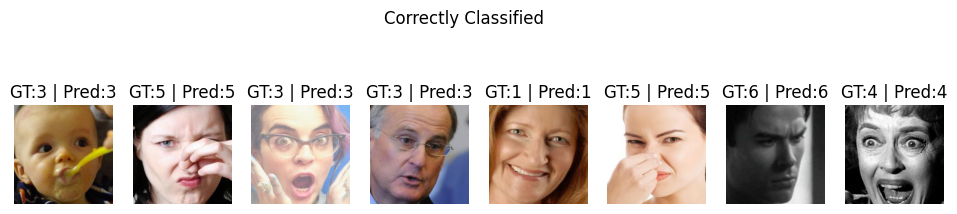

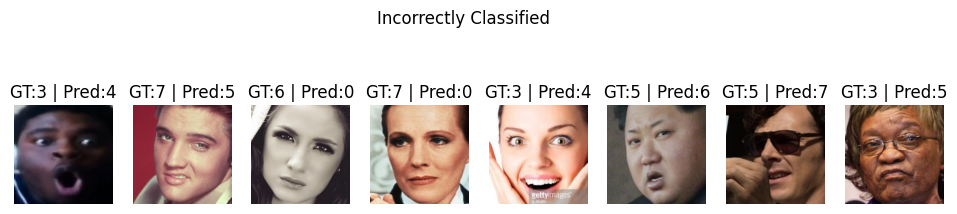

Mobilenet_v3_large examples:


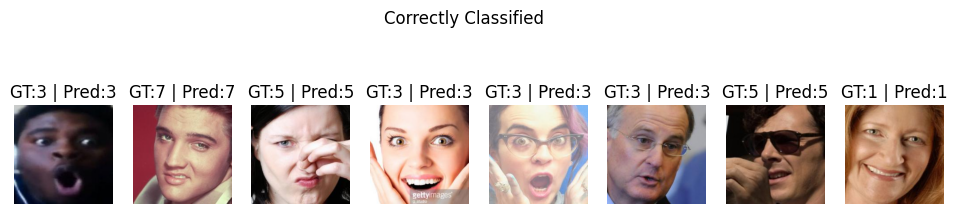

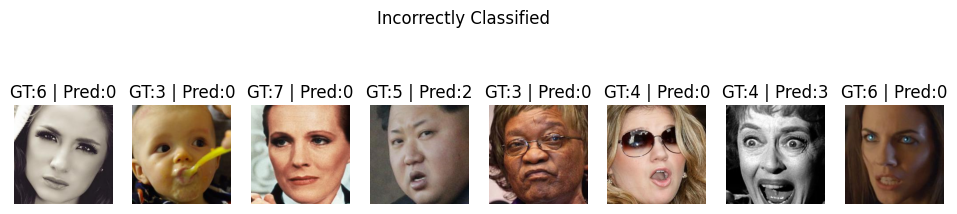

In [15]:
def show_examples(best_state, k=8):
    probs = best_state["metrics"]["probs"]
    y_true = best_state["metrics"]["y_true"]
    y_pred = best_state["metrics"]["y_pred"]
    stems  = best_state["metrics"]["stems"]

    correct = [i for i in range(len(y_true)) if y_true[i]==y_pred[i]]
    wrong   = [i for i in range(len(y_true)) if y_true[i]!=y_pred[i]]

    def grid(idxs, title):
        n = min(k, len(idxs))
        if n == 0:
            print(f"No {title.lower()} examples.")
            return
        plt.figure(figsize=(12, 3))
        for j,i in enumerate(idxs[:n]):
            img = Image.open(os.path.join(IMG_DIR, f"{stems[i]}.jpg")).convert("RGB")
            plt.subplot(1, n, j+1); plt.imshow(img); plt.axis('off')
            plt.title(f"GT:{y_true[i]} | Pred:{y_pred[i]}")
        plt.suptitle(title); plt.show()

    grid(correct, "Correctly Classified")
    grid(wrong, "Incorrectly Classified")

print("EfficientNet-B0 examples:")
show_examples(effb0_best, k=8)
print("Mobilenet_v3_large examples:")
show_examples(mbv3_best, k=8)


In [16]:
out_dir = "/content/drive/MyDrive/affect_outputs"
os.makedirs(out_dir, exist_ok=True)
comp_csv = os.path.join(out_dir, "model_comparison.csv")
comp_df.to_csv(comp_csv, index=False)
print("Saved:", comp_csv)


Saved: /content/drive/MyDrive/affect_outputs/model_comparison.csv
